# EA Occupation Mapping and Course Recommendation

**Author:** Natascha Sigle

**Date:** 12.07.2023

**Version:** 49.2.0

---

This prototype application was developed as a practical implementation of the concept for a strategic professional development model. The purpose of this prototype is to demonstrate the feasibility and potential benefits of automating the process of mapping an employee’s current skills to future roles based on an enterprise architecture (EA) model.

## Prototype Features

The prototype notebook incorporates the following key features:

1. **KldB/ESCO Skill profile development:** The application takes the current and previous KldB codes of employees as an input and developes a comprehensive skill profile of the employee

2. **Occupation Extraction from the EA:** From the uploaded Enterprise Architecture file, a number of ESCO professions are extracted that best match the skills required.

3. **Occupation Mapping:** Based on the analysis of KldB codes, the application generates recommendations for the most suitable occupations for each employee.

4. **Course Recommendation:** The notebook suggests relevant courses for each employee based on identified gaps between their current competencies and the desired skills for their future occupation. This helps employees pursue professional development opportunities aligned with their career aspirations and organizational needs.

## Usage

To use this notebook, follow the steps outlined in the previous introductory cell. The prototype is designed to allow organisations to load their EA model as an xml file and employee data, process the data as required, run the mapping process, analyse the results and implement the course suggestions.

## Legal Disclaimer

The information provided in this notebook is for educational and demonstrative purposes only. The author holds no liability for any consequences arising from the use or misuse of this notebook or any decisions made based on its output. Users are advised to verify and validate the results using appropriate methods and domain expertise.

## Disclaimer

The code in this notebook was written independently. During the writing process, Microsoft's GitHub Copilot was used to assist with programming and the "Code GPT by Jundini" extention was used to improve the code's readability by providing detailed comments.

- Microsofts GitHub Copilot: https://github.com/features/preview/copilot-x

- Code GPT by Jundini: https://codegpt.co/


Case Study:

61123-106 

61122-100

## Libraries


In [1]:
import os
import shutil
import tkinter as tk
from tkinter import filedialog, ttk, messagebox
import xml.etree.ElementTree as ET
import pandas as pd
from fuzzywuzzy import fuzz
import re
import warnings
import requests
from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

nltk.download('punkt')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

warnings.filterwarnings("ignore")

[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


## Functions


In [2]:
def filter_df_by_match_type(df, match_type):
    """
    Filter a DataFrame based on the provided match_type.

    Parameters:
        df (pandas.DataFrame): The DataFrame to be filtered.
        match_type (str): The type of match to filter by. Possible values are 'exactMatch', 'narrowMatch',
                          or 'closeMatch'.

    Returns:
        pandas.DataFrame: The filtered DataFrame.
    """

    # Define valid match types and their corresponding allowed match types
    valid_match_types = {
        "exactMatch": ['exactMatch'],
        "narrowMatch": ['exactMatch', 'narrowMatch'],
        "closeMatch": ['exactMatch', 'narrowMatch', 'closeMatch']
    }

    # Check if the provided match type is valid
    if match_type not in valid_match_types:
        raise ValueError("Invalid match type provided.")

    # Filter the dataframe based on the allowed match types for the provided match type
    filtered_df = df[df['MatchType'].isin(valid_match_types[match_type])]

    # Return the filtered dataframe
    return filtered_df


In [3]:
def select_row(df):
    """
    Function to let the user select a row from the matched profiles when there are several available.

    Parameters:
        df (pandas.DataFrame): The input DataFrame containing the data.

    Returns:
        pandas.DataFrame: A new DataFrame with selected rows based on user input.
    """

    # Find duplicate rows in the 'df' dataframe based on the 'KldbCode' column
    duplicates = df[df.duplicated(subset=['KldbCode'], keep=False)]

    # Create an empty list to store selected rows
    selected_rows = []

    # Iterate over each group of duplicates based on the 'KldbCode'
    for _, group in duplicates.groupby('KldbCode'):
        # Get the code of the duplicate group
        code = group['KldbCode'].iloc[0]

        # Filter the dataframe to get the rows with the same 'KldbCode' and select the 'code' and 'preferredLabel' columns
        label_df = df[df['KldbCode'] == code]
        label_df = label_df[['code', 'preferredLabel']].drop_duplicates()

        # Print the duplicate rows and their corresponding 'code' and 'preferredLabel' values
        print("Multiple rows found with the same KldbCode:", code)
        print(label_df)

        # Prompt the user to select a row or skip
        while True:
            print("Enter the index of the row to select (0, 1, ...), or 'q' to skip:")
            user_input = input()
            if user_input == 'q':
                break
            try:
                selected_index = int(user_input)
                if selected_index in [0, 1]:
                    selected_row = group.iloc[selected_index]
                    selected_rows.append(selected_row)
                    break
                else:
                    print("Invalid index. Please enter a valid index.")
            except ValueError:
                print("Invalid input. Please enter a valid index or 'q' to skip.")

    # Remove the duplicate rows from the 'df' dataframe
    df = df[~df.index.isin(duplicates.index)]

    # Append the selected rows to the 'df' dataframe
    df = df.append(selected_rows)

    # Return the updated dataframe
    return df


In [4]:
def count_matching_rows(df_Ress, df_occupation, df_occupations_en):
    """
    Count matching rows between the Ress DataFrame and occupation DataFrames.

    Args:
        df_Ress (pandas.DataFrame): The DataFrame containing Archimate resources.
        df_occupation (pandas.DataFrame): The DataFrame containing occupation data.
        df_occupations_en (pandas.DataFrame): The DataFrame containing occupations in English.

    Returns:
        pandas.DataFrame: The resulting DataFrame with matched rows.
    """

    # Get the columns that represent the skills in the occupation DataFrame
    skill_columns = [
        col for col in df_occupation.columns if col.startswith('Skill')]

    # Initialize a new DataFrame to store the results
    result_df = pd.DataFrame(columns=['OccupationCode', 'PreferredLabel', 'Description', 'Percentage', 'MatchCount', 'TotalCount',
                                      'MatchedSkills', 'UnmatchedSkills', 'RemainingSkills'])

    # Join df_occupation with df_occupations_en on OccupationCode to get occupation name and description
    df_occupation_merged = df_occupation.merge(df_occupations_en[['code', 'preferredLabel', 'description']],
                                               left_on='OccupationCode', right_on='code', how='left')

    # Iterate over each row in the merged occupation DataFrame
    for idx, row in df_occupation_merged.iterrows():
        # Get the skills from the row as a set for comparison
        occupation_skills = set(row[skill_columns].dropna().values)

        # List to store matched and unmatched skills
        matched_skills = []
        unmatched_skills = []

        # Iterate over each row in the df_Ress DataFrame
        for ress_row in df_Ress.itertuples(index=False):
            # Get the skills from the df_Ress row as a set
            ress_skills = set(ress_row.Resources.split(', '))

            # Check if all skills from df_Ress row are present in the occupation row
            if ress_skills.issubset(occupation_skills):
                # Add the matched skills to the list
                matched_skills.extend(ress_skills)
            else:
                # Add the unmatched skills to the list
                unmatched_skills.extend(ress_skills)

        # Calculate the match count and percentage
        match_count = len(matched_skills)
        total_skills = len(occupation_skills)
        percentage = round((match_count / total_skills) *
                           100, 2) if total_skills > 0 else 0

        # If match count is 0, skip the row
        if match_count == 0:
            continue

        # Get the remaining skills that are not matched or unmatched
        remaining_skills = occupation_skills - \
            (set(matched_skills) | set(unmatched_skills))
        result_row = {
            'OccupationCode': row['OccupationCode'],
            'PreferredLabel': row['preferredLabel'],
            'Description': row['description'],
            'Percentage': percentage,
            'MatchCount': match_count,
            'TotalCount': total_skills,
            # Skills that are matched in the Archimate Ressource df and the ESCO profile
            'MatchedSkills': ', '.join(matched_skills),
            # Unmatched skills that are in the Archimate Ressource df but not in the ESCO profile
            'UnmatchedSkills': ', '.join(set(unmatched_skills)),
            # Remaining skills are not used in the calculation but are in the ESCO profile
            'RemainingSkills': ', '.join(remaining_skills)
        }

        # Append the result row to the result DataFrame
        result_df = result_df.append(result_row, ignore_index=True)

    result_df = result_df[['OccupationCode', 'PreferredLabel', 'Description', 'Percentage', 'MatchCount', 'TotalCount',
                           'MatchedSkills', 'UnmatchedSkills', 'RemainingSkills']]

    # Sort the result DataFrame by Percentage in descending order
    result_df = result_df.sort_values(by='Percentage', ascending=False)
    result_df['Percentage'] = result_df['Percentage'].astype(int)

    # Remove rows with MatchCount = 0
    result_df = result_df[result_df['MatchCount'] > 1]

    # Find the maximum percentage value
    max_percentage = result_df['Percentage'].max()

    # Filter the dataframe to include rows with the maximum percentage value
    max_percentage_rows = result_df[result_df['Percentage'] == max_percentage]

    # If there are multiple rows with the same maximum percentage, select the row with the highest match count
    selected_row = max_percentage_rows[max_percentage_rows['MatchCount']
                                       == max_percentage_rows['MatchCount'].max()]

    # Return the selected row
    return selected_row


In [5]:
def execute_code_x_times(df_archimateResources, df_occSkills, df_occupations_en, x):
    """
    Executes a code block multiple times and accumulates the results.

    Args:
        df_archimateResources (pandas.DataFrame): The DataFrame containing Archimate resources.
        df_occSkills (pandas.DataFrame): The DataFrame containing occupation skills.
        df_occupations_en (pandas.DataFrame): The DataFrame containing occupations in English.
        x (int): The number of times to execute the code block - equal to the number of occupations to be found.

    Returns:
        tuple: A tuple containing two pandas DataFrames - df_archimateResources and accumulated_result.
            - df_archimateResources: The modified DataFrame after executing the code block x times.
            - accumulated_result: The accumulated results DataFrame.

    Explenation:
        The given code defines a function named "execute_code_x_times", which takes four arguments: "df_archimateResources", "df_occSkills", "df_occupations_en" and "x". This function executes a loop "x" number of times.
        In each iteration of the loop, the function calls another function named "count_matching_rows" with three arguments: "df_archimateResources", "df_occSkills" and "df_occupations_en". The returned result is stored in a variable named "df_result".
        If the returned result is not empty, the code extracts a string named "matchedSkills" from the "df_result". The code then removes any rows from "df_archimateResources" which contains any of the "matchedSkills" strings.
        Finally, the function appends the "df_result" in the "accumulated_result" using the "ignore_index=True" argument. After the loop has finished, the function returns two dataframes: "df_archimateResources" and "accumulated_result".
    """
    # Create an empty dataframe to accumulate the results
    accumulated_result = pd.DataFrame()

    # Perform the matching process 'x' times
    for _ in range(x):
        # Count the matching rows between the dataframes
        df_result = count_matching_rows(
            df_archimateResources, df_occSkills, df_occupations_en)

        # Check if the result dataframe is not empty
        if not df_result.empty:
            # Extract the matched skills from the first row of the result
            matchedSkills = df_result['MatchedSkills'].iloc[0].split(', ')

            # Remove rows from df_archimateResources that contain any of the matched skills
            df_archimateResources = df_archimateResources[~df_archimateResources['Resources'].apply(
                lambda x: any(skill in x for skill in matchedSkills))]

            # Reset the index of df_archimateResources
            df_archimateResources = df_archimateResources.reset_index(
                drop=True)

            # Append the result to the accumulated_result dataframe
            accumulated_result = accumulated_result.append(
                df_result, ignore_index=True)

    # Return the updated df_archimateResources dataframe and the accumulated_result dataframe
    return df_archimateResources, accumulated_result


In [6]:
def remove_subsequent_fuzzy_occurrences(skills):
    """
    Removes subsequent fuzzy occurrences of skills based on a similarity threshold.

    Parameters:
        skills (str): A string containing comma-separated skills.

    Returns:
        str: A modified string with subsequent fuzzy occurrences of skills removed.

    Example:
        skills = "Python, Java, C++, Python, JavaScript"
        result = remove_subsequent_fuzzy_occurrences(skills)
        print(result)
        # Output: "Python, Java, C++, JavaScript"

    Note:
        The function uses the `fuzz` module from the `fuzzywuzzy` package to calculate the partial ratio between skills.
        A skill is considered a fuzzy match if the partial ratio between two skills is greater than or equal to 97.
        The function preserves the first occurrence of a skill and removes subsequent occurrences that are fuzzy matches.
        The resulting string is returned with skills separated by commas and a space.
        If the input `skills` is None or empty, the function returns the input unchanged.
    """
    if pd.isnull(skills):
        return skills

    # Split the skills string into a list of individual skills
    skills_list = skills.split(', ')

    # Sort the skills list
    skills_list.sort()

    unique_skills = []  # List to store unique skills encountered
    result = []  # List to store filtered skills

    # Iterate through each skill in the skills list
    for skill in skills_list:
        if skill not in unique_skills:
            unique_skills.append(skill)
            result.append(skill)
        else:
            is_fuzzy_match = False
            # Check for fuzzy matches with previously encountered unique skills
            for unique_skill in unique_skills:
                ratio = fuzz.partial_ratio(skill, unique_skill)
                if ratio >= 97:
                    is_fuzzy_match = True
                    break
            if not is_fuzzy_match:
                result.append(skill)

    # Join the filtered skills list into a string separated by commas and return
    return ', '.join(result)


In [7]:
def calculate_skill_fit(df_currentOccupations, df_futureOccupations, df_skillRelation):
    """
    Calculates the skill fit between the current occupations and future occupations based on skill matching and counts.

    Parameters:
        df_currentOccupations (DataFrame): DataFrame containing the current occupation's description and skills.
        df_futureOccupations (DataFrame): DataFrame containing future occupations and their corresponding skills.
        df_skillRelation (DataFrame): DataFrame containing the relationship between occupations and skills.

    Returns:
        DataFrame: A DataFrame containing the calculated skill fit metrics for each future occupation.

    Example:
        df_currentOccupations = pd.DataFrame(...)
        df_futureOccupations = pd.DataFrame(...)
        df_skillRelation = pd.DataFrame(...)
        result = calculate_skill_fit(df_currentOccupations, df_futureOccupations, df_skillRelation)
        print(result)

    Note:
        - The function assumes that the column containing the current occupation's description skills in the `df_currentOccupations` DataFrame is located at index 0.
        - The function adds new columns to the `df_futureOccupations` DataFrame to store the matched and unmatched skills for each occupation.
        - The function performs skill matching by checking if the skills from the current occupation are present in each row of the `df_futureOccupations` DataFrame.
        - The function uses the `df_skillRelation` DataFrame to determine the relationship (essential or optional) between occupations and skills.
        - The skill fit metrics are calculated based on the counts of essential and optional skills matched with each occupation, the total number of skills, and the weighting of essential skills.
        - The function also removes subsequent fuzzy occurrences of skills in the 'Unmatched Skills' column using the 'remove_subsequent_fuzzy_occurrences' function.
    """

    # Get the skills from the current description
    current_description_skills = df_currentOccupations.iloc[0, 0:].values

    # Count the number of skills from the current description found in each row of df_futureOccupations
    # df_futureOccupations['MatchCount'] = df_futureOccupations.iloc[:, 1:].isin(
    #     current_description_skills).sum(axis=1)
    df_futureOccupations['MatchCount'] = 0
    # Create new columns to store the matched and unmatched skills for each occupation
    df_futureOccupations['MatchedSkills'] = df_futureOccupations.iloc[:, 1:].apply(
        lambda row: ', '.join(row[row.isin(current_description_skills)].dropna().astype(str)), axis=1)
    df_futureOccupations['UnmatchedSkills'] = df_futureOccupations.iloc[:, 1:].apply(
        lambda row: ', '.join(row[~row.isin(current_description_skills)].dropna().astype(str)), axis=1)

    # Create a new dataframe to store the result
    result_df = pd.DataFrame({
        'Occupation Code': df_futureOccupations['EscoCode'],
        'Match Count': df_futureOccupations['MatchCount'],
        'Matched Skills': df_futureOccupations['MatchedSkills'],
        'Unmatched Skills': df_futureOccupations['UnmatchedSkills']
    })

    # Reset the index of the result dataframe
    result_df.reset_index(drop=True, inplace=True)

    # Add new columns to store the count of essential and optional skills
    result_df['Essential Skills Count'] = 0
    result_df['Optional Skills Count'] = 0

    # Iterate over the rows of the result dataframe and count the essential and optional skills for each occupation code
    for index, row in result_df.iterrows():
        occupation_code = row['Occupation Code']
        matched_skills = row['Matched Skills'].split(', ')

        filtered_skills = df_skillRelation[(df_skillRelation['OccupationCode'] == occupation_code) & (
            df_skillRelation['PreferredSkillLabel'].isin(matched_skills))]

        essential_count = filtered_skills[filtered_skills['RelationType']
                                          == 'essential'].shape[0]
        optional_count = filtered_skills[filtered_skills['RelationType']
                                         == 'optional'].shape[0]

        result_df.at[index, 'Essential Skills Count'] = essential_count
        result_df.at[index, 'Optional Skills Count'] = optional_count

    # Calculate the total number of skills (matched + unmatched) for each occupation
    result_df['Total Skills Count'] = result_df['Matched Skills'].apply(lambda x: len(
        x.split(', '))) + result_df['Unmatched Skills'].apply(lambda x: len(x.split(', ')))

    result_df['Match Count'] = result_df['Essential Skills Count'] + result_df['Optional Skills Count']

    # Calculate the fit percentage with more weight on essential skills
    result_df['fit%'] = (result_df['Essential Skills Count'] +
                         result_df['Optional Skills Count']) / result_df['Total Skills Count'] * 100
    result_df['weightedFit%'] = (1.5 * result_df['Essential Skills Count'] +
                                 result_df['Optional Skills Count']) / result_df['Total Skills Count'] * 100

    # Add columns to store the matched essential and optional skills for each occupation
    result_df['Matched Skills Essential'] = ""
    result_df['Matched Skills Optional'] = ""

    # Iterate over the rows of the result dataframe and extract the matched essential and optional skills for each occupation
    for index, row in result_df.iterrows():
        matched_skills = row['Matched Skills'].split(', ')
        essential_skills = []
        optional_skills = []

        for skill in matched_skills:
            relation_types = df_skillRelation[(df_skillRelation['OccupationCode'] == row['Occupation Code']) & (
                df_skillRelation['PreferredSkillLabel'] == skill)]['RelationType'].values

            if len(relation_types) > 0:
                if 'essential' in relation_types:
                    essential_skills.append(skill)
                elif 'optional' in relation_types:
                    optional_skills.append(skill)

        result_df.at[index, 'Matched Skills Essential'] = ', '.join(
            essential_skills)
        result_df.at[index, 'Matched Skills Optional'] = ', '.join(
            optional_skills)

        result_df['Unmatched Skills'] = result_df['Unmatched Skills'].apply(
            remove_subsequent_fuzzy_occurrences)

    # Return the result dataframe
    return result_df


## GUI


### Input GUI


In [8]:
class UserInputGUI(tk.Tk):
    def __init__(self, df):
        tk.Tk.__init__(self)
        self.df = df
        self.title("KldB Codes")

        # Set the window size and disable resizing
        self.geometry("600x400")
        self.resizable(False, False)

        # Create labels and entry fields for current and previous KldB codes
        current_label = ttk.Label(self, text="Current KldB Code*:")
        current_label.grid(row=0, column=0, padx=10, pady=10)
        self.current_entry = ttk.Entry(self, width=50)
        self.current_entry.grid(row=0, column=1, padx=10, pady=10)

        # Create the options combobox
        self.options_combobox = ttk.Combobox(self, state="readonly", width=50)
        self.options_combobox.set(
            "Please select the occupation from the dropdown")
        self.options_combobox.grid(row=1, column=1, padx=10, pady=10)

        # Create the "Update" button
        update_button = ttk.Button(
            self, text="Update", command=self.update_options)
        update_button.grid(row=1, column=2, padx=10, pady=10)

        # Create labels and entry fields for previous KldB codes
        previous_label = ttk.Label(self, text="Previous KldB Code:")
        previous_label.grid(row=2, column=0, padx=10, pady=10)
        self.previous_entry = ttk.Entry(self, width=50)
        self.previous_entry.grid(row=2, column=1, padx=10, pady=10)

        # Create the options combobox for the previous KldB code
        self.previous_options_combobox = ttk.Combobox(
            self, state="readonly", width=50)
        self.previous_options_combobox.set(
            "Please select the occupation from the dropdown")
        self.previous_options_combobox.grid(row=3, column=1, padx=10, pady=10)

        # Create a label and entry field for additional user skills
        additional_skills_label = ttk.Label(
            self, text="Additional Skills (comma-separated):")
        additional_skills_label.grid(
            row=4, column=0, padx=10, pady=10, sticky='e')
        self.additional_skills_entry = ttk.Entry(self)
        self.additional_skills_entry.grid(
            row=4, column=1, padx=10, pady=10, sticky='w')

        # Create a separator line
        separator = ttk.Separator(self, orient='horizontal')
        separator.grid(row=5, column=0, columnspan=2,
                       padx=10, pady=10, sticky='ew')

        # Create a label for the file upload description
        upload_label = ttk.Label(self, text="Upload ArchiMate XML File:")
        upload_label.grid(row=6, column=0, padx=10, pady=10, sticky='e')

        # Create a label to display the selected file name
        self.file_label = ttk.Label(self, text="")
        self.file_label.grid(row=6, column=1, padx=10, pady=10, sticky='w')

        # Create a button to upload a file
        upload_button = ttk.Button(
            self, text="Upload File", command=self.upload_file)
        upload_button.grid(row=7, column=0, columnspan=2, padx=10, pady=10)

        # Create a button to save the input
        save_button = ttk.Button(self, text="Save", command=self.save_input)
        save_button.grid(row=8, column=0, columnspan=2, padx=10, pady=10)

        # Configure column weights for horizontal alignment
        self.grid_columnconfigure(0, weight=1)
        self.grid_columnconfigure(1, weight=1)

    def update_options(self):
        current_code = self.current_entry.get()
        previous_code = self.previous_entry.get()

        current_filtered_df = self.df[self.df['KldbCode'].str.startswith(
            f'B {current_code}')]
        current_options = [
            f"{row['KldbCode']} | {row['Classification 2 PrefLabel']}" for _, row in current_filtered_df.iterrows()]
        self.options_combobox['values'] = current_options

        previous_filtered_df = self.df[self.df['KldbCode'].str.startswith(
            f'B {previous_code}')]
        previous_options = [
            f"{row['KldbCode']} | {row['Classification 2 PrefLabel']}" for _, row in previous_filtered_df.iterrows()]
        self.previous_options_combobox['values'] = previous_options

    def upload_file(self):
        file_path = filedialog.askopenfilename(
            filetypes=[("XML Files", "*.xml")])
        if file_path:
            destination = os.path.join(
                "Resources", "Input", os.path.basename(file_path))
            try:
                os.makedirs(os.path.dirname(destination), exist_ok=True)
                shutil.copy(file_path, destination)
                print("File saved successfully.")
                self.file_label.config(text=os.path.basename(file_path))
            except Exception as e:
                print(f"Error saving file: {str(e)}")

    def save_input(self):
        current_kldb_string = self.options_combobox.get()
        previous_kldb_string = self.previous_options_combobox.get()

        current_kldb_code = current_kldb_string.split('|')[0].strip()
        previous_kldb_code = previous_kldb_string.split('|')[0].strip()

        additional_skills = self.additional_skills_entry.get()

        if current_kldb_code == "Please select the occupation from the dropdown":
            messagebox.showerror(
                "Invalid Input", "Please select a current KLDB Code.")
            return

        data = {
            'KLDB_Code': [current_kldb_code],
            'Previous_KLDB_Code': [previous_kldb_code],
            'Additional_User_Skills': [additional_skills]}

        self.df_currentKLDBs = pd.DataFrame(data)
        self.destroy()


### Result GUI


In [9]:
var_boxSize_height = 20
var_boxSize_width = 45

In [10]:
class UnmatchedSkillsGUI:
    def __init__(self, dataframe, df_occupations_en):
        # Initialize the UnmatchedSkillsGUI class
        self.dataframe = dataframe
        self.df_occupations_en = df_occupations_en
        self.window = tk.Tk()
        self.window.geometry("1650x600")
        self.window.title("Unmatched Skills")
        self.window.resizable(False, False)
        
        # Configure the style for the GUI elements
        style = ttk.Style(self.window)
        style.theme_use("clam")
        
        # Create labels and elements for the GUI
        self.heading_top_label = tk.Label(self.window, text='Result of the Mapping', font=("Arial", 18, "bold"))
        self.heading_top_label.grid(row=0, column=0, columnspan=4, pady=10)
        
        self.occupation_label = tk.Label(self.window, text="")
        self.description_label = tk.Label(self.window, text="")
        
        self.heading_essential_label = tk.Label(self.window, text='Matched Skills Essential', font=("Arial", 12))
        self.heading_essential_label.grid(row=2, column=0, padx=10, pady=5)
        
        self.heading_optional_label = tk.Label(self.window, text='Matched Skills Optional', font=("Arial", 12))
        self.heading_optional_label.grid(row=2, column=1, padx=10, pady=5)
        
        self.heading_unmatched_label = tk.Label(self.window, text='Missing Skills', font=("Arial", 12))
        self.heading_unmatched_label.grid(row=2, column=2, padx=10, pady=5)

        self.heading_matched_courses_label = tk.Label(self.window, text='Matched Courses', font=("Arial", 12))
        self.heading_matched_courses_label.grid(row=2, column=3, padx=10, pady=5)
        
        self.matched_courses_text_area = tk.Text(self.window, height=var_boxSize_height, width=var_boxSize_width+10)
        self.matched_courses_text_area.grid(row=3, column=3, padx=10)
        
        self.matched_essential_text_area = tk.Text(self.window, height=var_boxSize_height, width=var_boxSize_width)
        self.matched_optional_text_area = tk.Text(self.window, height=var_boxSize_height, width=var_boxSize_width)
        self.unmatched_text_area = tk.Text(self.window, height=var_boxSize_height, width=var_boxSize_width)

        self.close_button = tk.Button(self.window, text="Close", command=self.close_window)
        
    def display(self,df_matchedCourses):
        # Retrieve the occupation code with the highest weightedFit%
        highest_weightedfit_row = self.dataframe[self.dataframe['weightedFit%'] == self.dataframe['weightedFit%'].max()]
        occupation_code = highest_weightedfit_row['Occupation Code'].values[0]
        
        # Extract unmatched skills, matched essential skills, and matched optional skills
        unmatched_skills = highest_weightedfit_row['Unmatched Skills'].values[0]
        unmatched_skills_list = re.findall(r"[a-zA-Z\s]+", unmatched_skills)
        unmatched_skills_list = [skill.strip() for skill in unmatched_skills_list if skill.strip()]
        unmatched_skills_list = list(set(unmatched_skills_list))
        unmatched_skills_list.sort()

        matched_essential_skills = highest_weightedfit_row['Matched Skills Essential'].values[0]
        matched_essential_list = re.findall(r"[a-zA-Z\s]+", matched_essential_skills)
        matched_essential_list = [skill.strip() for skill in matched_essential_list if skill.strip()]
        matched_essential_list = list(set(matched_essential_list))
        matched_essential_list.sort()

        matched_optional_skills = highest_weightedfit_row['Matched Skills Optional'].values[0]
        matched_optional_list = re.findall(r"[a-zA-Z\s]+", matched_optional_skills)
        matched_optional_list = [skill.strip() for skill in matched_optional_list if skill.strip()]
        matched_optional_list = list(set(matched_optional_list))
        matched_optional_list.sort()

        # Insert matched courses into the matched courses text area
        for _, course in df_matchedCourses.iterrows():
            self.matched_courses_text_area.insert(tk.END, f"\n=======================\nCourse: {course['Title']}\nURL: {course['URL']}\n")
        
        occupation_name = self.df_occupations_en.loc[self.df_occupations_en['code'] == occupation_code, 'preferredLabel'].values[0]
        occupation_name = occupation_name.title()
            
        self.occupation_label.config(text=f"Future Occupation: {occupation_name}", font=("Arial", 15))
        self.occupation_label.grid(row=1, column=0, columnspan=4, pady=10)
        
        self.matched_essential_text_area.insert(tk.END, "\n".join(matched_essential_list))
        self.matched_essential_text_area.grid(row=3, column=0, padx=10, pady=10)
        
        self.matched_optional_text_area.insert(tk.END, "\n".join(matched_optional_list))
        self.matched_optional_text_area.grid(row=3, column=1, padx=10, pady=10)
        
        self.unmatched_text_area.insert(tk.END, "\n".join(unmatched_skills_list))
        self.unmatched_text_area.grid(row=3, column=2, padx=10, pady=10)
        
        self.description_label.grid(row=4, column=0, columnspan=4, pady=10)
        self.close_button.grid(row=5, column=0, columnspan=4, pady=10)
        self.window.mainloop()
        
    def close_window(self):
        self.window.destroy()


## Data Loading


![Alt text](image-2.png)

### ESCO Data


In [11]:
# base file for the initial creation of the mapping file
df_kldbMapping = pd.read_csv('Resources/ESCO/KLDBMapping.csv')
# processed mapping file used for the selection of the KLDB codes in the input GUI
df_kldbOccupationMapping = pd.read_csv(
    'Resources\ESCO\kldbOccupationMapping.csv')

In [12]:
df_occupationSkillRelations = pd.read_csv(
    'Resources/ESCO/occupationSkillRelations.csv')
df_occupations_en = pd.read_csv("Resources/ESCO/occupations_en.csv")
df_skills_en = pd.read_csv("Resources/ESCO/skills_en.csv")


In [13]:
df_skills_en.head(1).T

,0
conceptType,KnowledgeSkillCompetence
conceptUri,http://data.europa.eu/esco/skill/0005c151-5b5a...
skillType,skill/competence
reuseLevel,sector-specific
preferredLabel,manage musical staff
altLabels,manage staff of music\ncoordinate duties of mu...
hiddenLabels,NaN
status,released
modifiedDate,2016-12-20T17:43:43Z
scopeNote,NaN


### User Input


In [14]:
inputGui = UserInputGUI(df_kldbOccupationMapping)
inputGui.mainloop()

df_currentKLDBs = inputGui.df_currentKLDBs
df_currentKLDBs.loc[df_currentKLDBs['Previous_KLDB_Code'] ==
                    'Please select the occupation from the dropdown', 'Previous_KLDB_Code'] = ''


### Archimate Input


In [15]:
# Parse the XML file
tree = ET.parse('Resources\Input\DigiFan.xml')

root = tree.getroot()

# Define the XML namespace and prefix map
namespace = {'ns': 'http://www.opengroup.org/xsd/archimate/3.0/',
             'xsi': 'http://www.w3.org/2001/XMLSchema-instance'}

data = []

# Find all elements with xsi:type="Ressource"
ressource_elements = root.findall(
    './/ns:element[@xsi:type="Resource"]', namespace)
# capability_elements = root.findall('.//ns:element[@xsi:type="Capability"]', namespace)

# Iterate over the "Ressource" elements and extract the data
for element in ressource_elements:
    row = {}
    for child in element:
        row[child.tag] = child.text
    data.append(row)

# Create a DataFrame from the data
df_archimateResources = pd.DataFrame(data)


In [16]:
df_archimateResources.head()

,{http://www.opengroup.org/xsd/archimate/3.0/}name
0,Wind Turbine Dataset
1,IoT Sensors
2,Anomaly Detection Algorithm
3,Python
4,SQL


## Data Preperation


![Alt text](image-3.png)

#### Data merging


In [17]:
# Replace newline characters with commas in the 'altLabels' column of df_skills_en dataframe
df_skills_en['altLabels'] = df_skills_en['altLabels'].str.replace('\n', ',')

# Merge df_occupationSkillRelations, df_occupations_en, and df_skills_en dataframes based on specific columns
df_merged = df_occupationSkillRelations.merge(
    df_occupations_en, left_on='occupationUri', right_on='conceptUri', how='left')
df_merged = df_merged.merge(
    df_skills_en, left_on='skillUri', right_on='conceptUri', how='left')

# Convert the 'preferredLabel_x' column to lowercase and remove non-alphanumeric characters
df_merged['preferredLabel_x'] = df_merged['preferredLabel_x'].str.lower(
).str.replace('[^a-zA-Z0-9\s]', '')

# Save the resulting merged dataframe to a CSV file
df_merged.to_csv('Resources/Output/merged.csv', index=False)


#### Occupation Skill Profile


In [18]:
# Select specific columns from df_merged and rename them
df_codeLabel = df_merged[['code', 'preferredLabel_y', 'altLabels_y']].rename(
    columns={'code': 'OccupationCode', 'preferredLabel_y': 'PreferredSkillLabel', 'altLabels_y': 'AlternativSkillLabel'})
df_codeLabel

,OccupationCode,PreferredSkillLabel,AlternativSkillLabel
0,2654.1.7,theatre techniques,"theatre technique,theatre approaches,theater ..."
1,2654.1.7,organise rehearsals,"organise rehearsal,organize rehearsals,plan re..."
2,2654.1.7,write risk assessment on performing arts produ...,write assessment of risks about performing art...
3,2654.1.7,coordinate with creative departments,"liaise with other artistic departments,coordin..."
4,2654.1.7,adapt to artists' creative demands,"meet demands by creative artists,adapt to dema..."
...,...,...,...
123850,8211.5,tend riveting machine,"watch over tacking machine,oversee riveting ma..."
123851,8211.5,set up automotive robot,"erect automotive robotic machining systems,arr..."
123852,8211.5,evaluate engine performance,"analyse performance of engines,analyse engine ..."
123853,8211.5,operate soldering equipment,"handle bonding and welding equipment,run solde..."


In [19]:
# Group the rows by 'OccupationCode' and join the 'PreferredSkillLabel' and 'AlternativSkillLabel' values
df_occSkills = df_codeLabel.groupby('OccupationCode').apply(
    lambda x: ';'.join(map(str, x['PreferredSkillLabel'])) + ';'.join(
        map(lambda skill: skill.replace(', ', ',') if pd.notnull(skill) else '', x['AlternativSkillLabel']))).reset_index(name='Skills')

# Split the values in the 'Skills' column by ';' or ','
df_occSkills['Skills'] = df_occSkills['Skills'].str.split(r';|,')

In [20]:
df_occSkillsE = df_occSkills[~df_occSkills['OccupationCode'].str.startswith(('0', '11'))]
df_occSkillsE.head(2)

,OccupationCode,Skills
44,1211.1,"[financial statements, financial management, f..."
45,1211.1.1,"[accounting department processes, financial de..."


In [21]:
# Find the maximum number of skills in the 'Skills' column
max_skills = df_occSkills['Skills'].apply(len).max()

# Create a list of column names for the skills
skill_columns = [f"Skill{i+1}" for i in range(max_skills)]

# Split the 'Skills' column into separate columns using a DataFrame and assign them the skill_columns
df_occSkills[skill_columns] = pd.DataFrame(df_occSkills['Skills'].tolist())

# Remove the original 'Skills' column
df_occSkills.drop(['Skills'], axis=1, inplace=True)

# Remove any columns that have all NaN values
df_occSkills.dropna(axis=1, how='all', inplace=True)


In [22]:
df_occSkillsE = df_occSkills[~df_occSkills['OccupationCode'].str.startswith(('0', '11'))]
df_occSkillsE.head(2)

,OccupationCode,Skill1,Skill2,Skill3,Skill4,Skill5,Skill6,Skill7,Skill8,Skill9,...,Skill2911,Skill2912,Skill2913,Skill2914,Skill2915,Skill2916,Skill2917,Skill2918,Skill2919,Skill2920
44,1211.1,financial statements,financial management,financial analysis,enforce financial policies,analyse market financial trends,strive for company growth,create a financial plan,advise on financial matters,analyse financial performance of a company,...,None,None,None,None,None,None,None,None,None,None
45,1211.1.1,accounting department processes,financial department processes,financial statements,international financial reporting standards,financial management,fraud detection,depreciation,corporate social responsibility,financial analysis,...,None,None,None,None,None,None,None,None,None,None


#### Archimate Data Preperation


In [23]:
# Renaming the column '{http://www.opengroup.org/xsd/archimate/3.0/}name' to 'Resources'
df_archimateResources = df_archimateResources.rename(
    columns={'{http://www.opengroup.org/xsd/archimate/3.0/}name': 'Resources'})

# Stripping, lowercasing, and removing any special characters from the 'Resources' column
df_archimateResources = df_archimateResources['Resources'].str.strip(
).str.lower().replace('[^a-zA-Z0-9\s]', '')

# Sorting the values in the 'Resources' column and resetting the index
df_archimateResources = df_archimateResources.sort_values().reset_index(drop=True)

# Creating a new DataFrame with the 'Resources' column
df_archimateResources = pd.DataFrame(
    df_archimateResources, columns=['Resources'])


#### User Data Preperation


In [24]:
# Split the values in the 'Additional_User_Skills' column by comma and convert it into a list
df_currentKLDBs["Additional_User_Skills"] = df_currentKLDBs["Additional_User_Skills"].str.split(
    ", ")

# Create new columns for each skill in the 'Additional_User_Skills' column
max_skills = df_currentKLDBs["Additional_User_Skills"].apply(len).max()
if max_skills > 0:
    for i in range(max_skills):
        # Generate a column name for each skill
        skill_col_name = f"Skill_{i+1}"
        # Extract the skill value at index i from the list and assign it to a new column
        df_currentKLDBs[skill_col_name] = df_currentKLDBs["Additional_User_Skills"].str[i]

# Remove leading and trailing whitespaces from all columns
df_currentKLDBs = df_currentKLDBs.applymap(
    lambda x: x.strip() if isinstance(x, str) else x)

# Remove the 'Additional_User_Skills' column
df_currentKLDBs.drop("Additional_User_Skills", axis=1, inplace=True)


In [25]:
# Select specific columns from the 'df_merged' dataframe and rename them in the 'df_skillRelation' dataframe
df_skillRelation = df_merged[['code', 'preferredLabel_y', 'relationType']].rename(
    columns={'code': 'OccupationCode', 'preferredLabel_y': 'PreferredSkillLabel', 'relationType': 'RelationType'})


## Creation of the individual competence profiles


![Alt text](image-4.png)

In [26]:
df_currentKLDBs

,KLDB_Code,Previous_KLDB_Code,Skill_1
0,B 61123-106,B 61122-100,


In [27]:
# Get the ESCO Codes for the provided KLDB Codes

# Join the 'df_currentKLDBs' dataframe with the 'df_kldbOccupationMapping' dataframe based on the 'KLDB_Code' column
df_currentEscoSkillset = df_currentKLDBs.join(
    df_kldbOccupationMapping.set_index('KldbCode')['code'], on='KLDB_Code')

# Rename the joined column as 'CurrentEscoCode'
df_currentEscoSkillset.rename(
    columns={'code': 'CurrentEscoCode'}, inplace=True)

# Join the 'df_currentEscoSkillset' dataframe with the 'df_kldbOccupationMapping' dataframe based on the 'Previous_KLDB_Code' column
df_currentEscoSkillset = df_currentEscoSkillset.join(
    df_kldbOccupationMapping.set_index('KldbCode')['code'], on='Previous_KLDB_Code')

# Rename the joined column as 'PrevEscoCode'
df_currentEscoSkillset.rename(columns={'code': 'PrevEscoCode'}, inplace=True)


In [29]:
df_currentEscoSkillset

,KLDB_Code,Previous_KLDB_Code,Skill_1,CurrentEscoCode,PrevEscoCode
0,B 61123-106,B 61122-100,,3322.1,4311.2


In [30]:
# Get the skillset for the two provided ESCO Codes

# Merge the 'df_currentEscoSkillset' dataframe with the 'df_occSkills' dataframe based on the 'CurrentEscoCode' and 'OccupationCode' columns
df_currentEscoSkillset2 = df_currentEscoSkillset.merge(
    df_occSkills, left_on='CurrentEscoCode', right_on='OccupationCode', how='left')

# Merge the 'df_currentEscoSkillset2' dataframe with the 'df_occSkills' dataframe based on the 'PrevEscoCode' and 'OccupationCode' columns
df_currentEscoSkillset2 = df_currentEscoSkillset2.merge(
    df_occSkills, left_on='PrevEscoCode', right_on='OccupationCode', how='left')


In [31]:
# Identify columns with all null values in the 'df_currentEscoSkillset2' dataframe
empty_columns = df_currentEscoSkillset2.columns[df_currentEscoSkillset2.isnull(
).all()]

# Drop columns with all null values from the 'df_currentEscoSkillset2' dataframe
df_currentEscoSkillset3 = df_currentEscoSkillset2.drop(empty_columns, axis=1)

# Iterate over each column in the 'df_currentEscoSkillset3' dataframe
for column in df_currentEscoSkillset3.columns:
    # Fill null values in the column with empty strings and convert to string type
    df_currentEscoSkillset3[column] = df_currentEscoSkillset3[column].fillna(
        '').astype(str)
    # Remove extra whitespaces within each value in the column
    df_currentEscoSkillset3[column] = df_currentEscoSkillset3[column].apply(
        lambda x: ' '.join(x for x in x.split() if x != ''))


In [32]:
# Join the 'df_currentEscoSkillset3' dataframe with the 'df_occupations_en' dataframe based on the 'code' column and 'CurrentEscoCode' column
df_currentOccupations = df_currentEscoSkillset3.join(
    df_occupations_en.set_index('code')['preferredLabel'], on='CurrentEscoCode')

# Rename the columns in the 'df_currentOccupations' dataframe
df_currentOccupations = df_currentOccupations.rename(
    columns={'KLDB_Code': 'KldbCode', 'preferredLabel': 'Current ESCO Title'})


In [33]:
# Select specific rows from the df_currentOccupations dataframe based on certain criteria
df_currentOccupations = select_row(df_currentOccupations)

In [34]:
# Create an empty set to store unique values
unique_content = set()

# Create an empty list to store columns to be removed
columns_to_remove = []

# Iterate over each column in the df_currentOccupations dataframe
for column in df_currentOccupations.columns:
    # Iterate over each value in the column
    for value in df_currentOccupations[column]:
        # Check if the value is already present in the unique_content set
        if value in unique_content:
            # If value is already present, add the column to the columns_to_remove list
            columns_to_remove.append(column)
        else:
            # If value is not present, add it to the unique_content set
            unique_content.add(value)

# Drop the columns specified in the columns_to_remove list from the df_currentOccupations dataframe
df_currentOccupations = df_currentOccupations.drop(columns=columns_to_remove)


In [35]:
# Output to check the current occupation
df_currentOccupations[['KldbCode', 'CurrentEscoCode', 'Current ESCO Title','Skill1_x','Skill2_x']]


,KldbCode,CurrentEscoCode,Current ESCO Title,Skill1_x,Skill2_x
0,B 61123-106,3322.1,commercial sales representative,characteristics of products,sales promotion techniques


In [36]:
# Remove the specified columns from the 'df_currentOccupations' dataframe
df_currentOccupations.drop(
    ["KldbCode", "CurrentEscoCode", 'Current ESCO Title'], axis=1, inplace=True)


## Derivation of required professions from the enterprise architecture model 


![Alt text](image-11.png)

In [37]:
# Execute code 'x' times to match skills between the Archimate Resource dataframe and the ESCO profiles
unmatchedSkills, matchedSkillProfiles = execute_code_x_times(
    df_archimateResources, df_occSkills, df_occupations_en, 4)


In [38]:
matchedSkillProfiles

,OccupationCode,PreferredLabel,Description,Percentage,MatchCount,TotalCount,MatchedSkills,UnmatchedSkills,RemainingSkills
0,2511.3,data analyst,"Data analysts import, inspect, clean, transfor...",8,17,210,"analyse big data, apply statistical analysis t...","pyspark, crisp-dm, write technical reports, da...",", wikiCalc, managing quantitative data, XQuery..."
1,1420.3,sales account manager,Sales account managers serve as intermediators...,4,10,230,"build business relationships, characteristics ...","pyspark, crisp-dm, write technical reports, da...","ask questions referring to documents, policies..."
2,3119.10,metal additive manufacturing operator,Metal additive manufacturing operators operate...,2,4,195,"maintenance operations, perform machine mainte...","pyspark, crisp-dm, write technical reports, da...","solve problems, calibrate laser, machine equip..."
3,2141.8,maintenance and repair engineer,Maintenance and repair engineers focus on the ...,1,9,715,"assemble sensors, conduct routine machinery ch...","pyspark, mdx, python, crisp-dm, databricks, po...","compose technical reports, , circuit boards, c..."


In [39]:
try:
    # Filter the 'df_occSkills' dataframe based on the 'OccupationCode' column using values from 'matchedSkillProfiles'
    df_futureOccupations = df_occSkills[df_occSkills['OccupationCode'].isin(
        matchedSkillProfiles['OccupationCode'])]

    # Rename the 'OccupationCode' column to 'EscoCode'
    df_futureOccupations = df_futureOccupations.rename(
        columns={'OccupationCode': 'EscoCode'})

    # Remove leading and trailing whitespaces from all columns
    df_futureOccupations = df_futureOccupations.applymap(
        lambda x: x.strip() if isinstance(x, str) else x)

except KeyError:
    # Handle the case when no matching occupation is found for the chosen XML file
    print("No matching occupation found for the chosen XML file.")


## Matching of an employee with the identified occupations

![Alt text](image-6.png)

In [40]:
# Calculate the skill fit between current occupations, future occupations, and skill relations
df_fittingResult = calculate_skill_fit(
    df_currentOccupations, df_futureOccupations, df_skillRelation)


In [41]:
# Define the desired column order
desired_columns = ["Occupation Code", "Match Count", "Essential Skills Count", "Optional Skills Count", "Total Skills Count", "fit%", "weightedFit%", "Matched Skills Essential","Matched Skills Optional","Unmatched Skills"]

# Reorder the DataFrame columns
df_fittingResult = df_fittingResult[desired_columns]
df_fittingResult = df_fittingResult.sort_values(by="weightedFit%", ascending=False)
df_fittingResult = df_fittingResult.reset_index(drop=True)
df_fittingResult

# 1420.3 -> Sales Account Manager

,Occupation Code,Match Count,Essential Skills Count,Optional Skills Count,Total Skills Count,fit%,weightedFit%,Matched Skills Essential,Matched Skills Optional,Unmatched Skills
0,1420.3,13,10,3,370,3.513514,4.864865,"characteristics of products, customer service,...","consumer protection, speak different languages...","0, accounting approaches, accounting methods, ..."
1,2141.8,2,0,2,831,0.240674,0.240674,,"chemical products, apply technical communicati...",", 0, Infovis, Infoviz, MRO, QA procedure, a ch..."
2,2511.3,0,0,0,262,0.000000,0.000000,,,", .QL, 0, Ability Office Spreadsheet, Accel Sp..."
3,3119.10,0,0,0,216,0.000000,0.000000,,,"0, MRO, QA procedure, a metal and metal ore pr..."


![Alt text](image-7.png)

In [42]:
# Apply the function to the relevant columns
df_fittingResult['Unmatched Skills'] = df_fittingResult['Unmatched Skills'].apply(
    remove_subsequent_fuzzy_occurrences)
df_fittingResult['Matched Skills Essential'] = df_fittingResult['Matched Skills Essential'].apply(
    remove_subsequent_fuzzy_occurrences)
df_fittingResult['Matched Skills Optional'] = df_fittingResult['Matched Skills Optional'].apply(
    remove_subsequent_fuzzy_occurrences)

## Identification of suitable further training measures


![Alt text](image-8.png)

In [43]:
# Min 18
df_courses = pd.read_csv('Resources/Input/Udemy_Course_Desc.csv')

In [44]:
# Sorting the DataFrame by 'weightedFit%' column in descending order
sorted_df = df_fittingResult.sort_values(by='weightedFit%', ascending=False)

# Getting the top row of the sorted DataFrame
top_row = sorted_df.iloc[0]

# Extracting the 'Unmatched Skills' value from the top row
unmatched_skills = top_row['Unmatched Skills']

unmatched_skills = re.sub('\d', '', unmatched_skills)
skills = unmatched_skills.split(', ')
skills = unmatched_skills.split(' ')

# Filtering out any stopwords from the list of skills
skills = [w for w in skills if not w in stop_words]

In [45]:
# Outputting the filtered list of unmatched skills
unmatched_skills

", accounting approaches, accounting methods, accounting performance, accounting skills, accounting technique, accounting techniques, adapt to a changing situation, adapt to changing situations, adapting to a changing situation, adapting to changing situations, adjust to changing situations, administer company policies, administer customer follow-up, adopt content management system software, adopt customer relationship management software, agree on prices, alter to changing situations, analyse data performance, analyse sales levels of products, anticipate account metrics, apply communication techniques, apply company policies, apply company policy, apply content management system software, apply customer relationship management software, applying company policies, ask questions referring to documents, aspects of products, aspects of services, assemble business relationships, assure client orientation, attributes of products, attributes of services, build a business relationship, build 

In [46]:
skills[3:10]

['accounting',
 'methods,',
 'accounting',
 'performance,',
 'accounting',
 'skills,',
 'accounting']

In [47]:
df_courses['Title'] = df_courses['Title'].str.lower().replace('\n',
                                                              ' ', regex=True)
df_courses['Headline'] = df_courses['Headline'].str.lower().replace('\n',
                                                                    ' ', regex=True)
df_courses['Description'] = df_courses['Description'].str.lower().replace(
    '\n', ' ', regex=True)


In [48]:
# Initialize an empty list to store the matched skills for each course
df_courses['matched_skills'] = [[] for _ in range(len(df_courses))]

# Initialize a column to store the count of matched skills for each course
df_courses['matched_skills_count'] = 0

# For each course, check which skills appear in its 'Content' and 'Desc'
# and update 'matched_skills' and 'matched_skills_count'
for skill in skills:
    for i in range(len(df_courses)):
        if skill in df_courses.loc[i, 'Headline'] or skill in df_courses.loc[i, 'Description']:
            df_courses.at[i, 'matched_skills'].append(skill)
            df_courses.at[i, 'matched_skills_count'] += 1

# top_2_threshold = df_courses['matched_skills_count'].quantile(0.98)
# df_matchedCourses = df_courses[df_courses['matched_skills_count']>= top_2_threshold]
df_courses = df_courses.sort_values(by='matched_skills_count', ascending=False)
df_courses.head(4)

,URL,Title,Headline,Description,Price,Language,matched_skills,matched_skills_count
491,https://www.udemy.com/course/sql-for-real-worl...,sql for data analysis: solving real-world prob...,a simple & concise mysql course (applicable to...,note on the short version of the course i have...,Free,en_US,"[,, company, customer, management, customer, m...",207
17,https://www.udemy.com/course/complete-ai-guide/,"chatgpt complete guide: learn midjourney, chat...",chatgpt plugins + 25 powerful ai tools 10x you...,have you been hearing about the amazing thing...,€94.99,en_US,"[,, changing, changing, changing, changing, ch...",207
125,https://www.udemy.com/course/instagram-marketi...,instagram marketing: complete guide to instagr...,"attract hyper-targeted instagram followers, co...",**brand new content & up to date! - complete ...,€119.99,en_US,"[,, techniques,, customer, content, management...",201
469,https://www.udemy.com/course/gptcourse/,prompt engineering with chatgpt 4 & midjourney...,create 10 projects with chatgpt4 & midjourney ...,course contains 4 modules as outlines below: ...,€19.99,en_US,"[,, skills,, customer, content, system, custom...",200


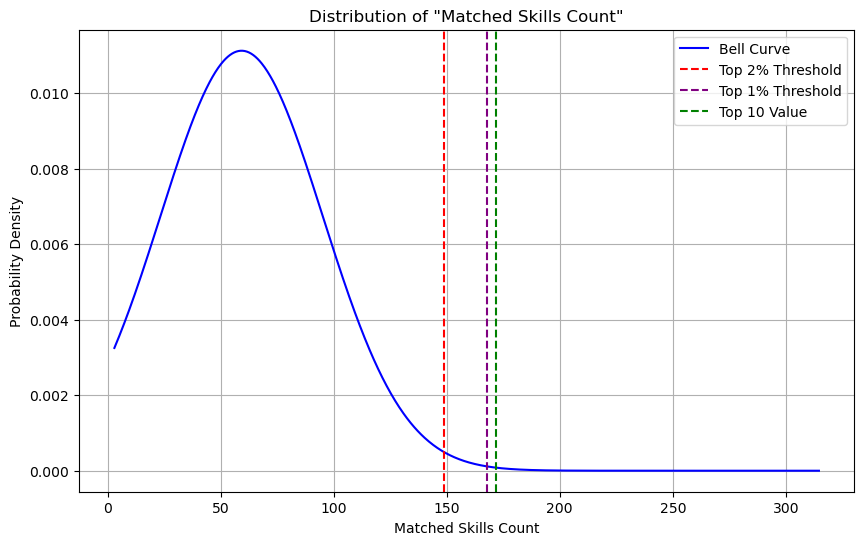

In [49]:
matched_skills_count = df_courses['matched_skills_count']

# Calculate mean and standard deviation
mu, std = np.mean(matched_skills_count), np.std(matched_skills_count)

# Calculate the threshold values for the top 2% and top 1% of the distribution
threshold_value_2_percent = np.percentile(matched_skills_count, 98)
threshold_value_1_percent = np.percentile(matched_skills_count, 99)

# Get the value of the 10th highest matched_skills_count
top_10_value = matched_skills_count.nlargest(10).iloc[-1]

# Create a range of values
x = np.linspace(min(matched_skills_count), max(matched_skills_count) + 3*std, 1000)

bell_curve = norm.pdf(x, mu, std)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x, bell_curve, color='blue', label='Bell Curve')
plt.axvline(x=threshold_value_2_percent, color='red', linestyle='dashed', label='Top 2% Threshold')
plt.axvline(x=threshold_value_1_percent, color='purple', linestyle='dashed', label='Top 1% Threshold')
plt.axvline(x=top_10_value, color='green', linestyle='dashed', label='Top 10 Value')
plt.title('Distribution of "Matched Skills Count"')
plt.xlabel('Matched Skills Count')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()


In [50]:
matched_skills_count = df_courses['matched_skills_count']

# Calculate the thresholds
threshold_value_2_percent = np.percentile(matched_skills_count, 98)
threshold_value_1_percent = np.percentile(matched_skills_count, 99)
top_10_courses = df_courses.nlargest(10, 'matched_skills_count')
top_10_matched_skills_count = top_10_courses['matched_skills_count']

# Count the number of courses in the top 1 and 2%
num_courses_in_top_2_percent = len(matched_skills_count[matched_skills_count >= threshold_value_2_percent])
num_courses_in_top_1_percent = len(matched_skills_count[matched_skills_count >= threshold_value_1_percent])

# Print the results
print(f"Number of courses in the top 2%: {num_courses_in_top_2_percent}")
print(f"Number of courses in the top 1%: {num_courses_in_top_1_percent}")


Number of courses in the top 2%: 24
Number of courses in the top 1%: 12


## Result


In [51]:
# Find the top ten courses with the highest number of matched skills
df_matchedCourses = df_courses.iloc[:10]

In [52]:
# Create a GUI instance
gui = UnmatchedSkillsGUI(df_fittingResult, df_occupations_en)
gui.display(df_matchedCourses)


## Generation of the Udemy extract

The following part of this notebook contains archived code that has been used to generate an input file for the udemy courses. Since the generation of the file is very time consuming, it is generated once and then stored to reduce the runtime of the notebook. The code below can be executed to update the files.


In [53]:
# This token was generated for the extraction of the course information from the Udemy API.
# A token is linked to the personal Udemy account and can be requested here: https://www.udemy.com/user/edit-api-clients/

# MyToken = "Basic ZE....."

# def clean_description(description):
#     soup = BeautifulSoup(description, 'html.parser')
#     cleaned_text = soup.get_text(separator=' ')
#     return cleaned_text.replace('\n', ' ').replace('\r', '').strip()

# # Initialize the page number
# page = 1

# # The headers (replace 'your_token' with your actual token)
# headers = {
#     "Authorization": MyToken
# }

# # Prepare a list to hold our processed results
# data = []

# # Retrieve data from 7 pages
# for page in range(1, 100):
#     # The API URL
#     url = f"https://www.udemy.com/api-2.0/courses/?fields[course]=@all&page={page}"

#     # Make the GET request
#     response = requests.get(url, headers=headers)

#     # Parse the response as JSON
#     response_data = response.json()

#     # Extract results from the response
#     results = response_data['results']

#     # Process each result
#     for result in results:
#         # Extract the locale information
#         locale = result['locale']['locale']

#         # Only process the result if the locale is 'en_US'
#         if locale == 'en_US':
#             # Extract the required fields
#             url = "https://www.udemy.com" + result['url']
#             title = result['title']
#             headline = result['headline']

#             # Clean the description
#             description = clean_description(result['description'])

#             price = result['price']

#             # Append the processed result to our data list
#             data.append([url, title, headline, description, price, locale])

# # Convert the list to a DataFrame
# df = pd.DataFrame(data, columns=['URL', 'Title', 'Headline', 'Description', 'Price', 'Language'])
# # Let's define a function to clean up the HTML and remove line breaks

# df['Description'] = df['Description'].apply(clean_description)

# df.to_csv(r'Resources\Input\Udemy_Course_Desc.csv', index=False)
# df
